<>:45: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
<>:45: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_17356\3584741329.py:45: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
  sciezka_do_pliku = "C:/Users\HP\Desktop\stuff\eolabs-main\lab_5\Obrazy_lotnicze/221000_Odra_HS_Blok_A_008_VS_join_atm.bsq"


Wczytywanie kanałów: (50, 30, 10)
Rozmiar: 2001x4300, Liczba wszystkich pasm: 456


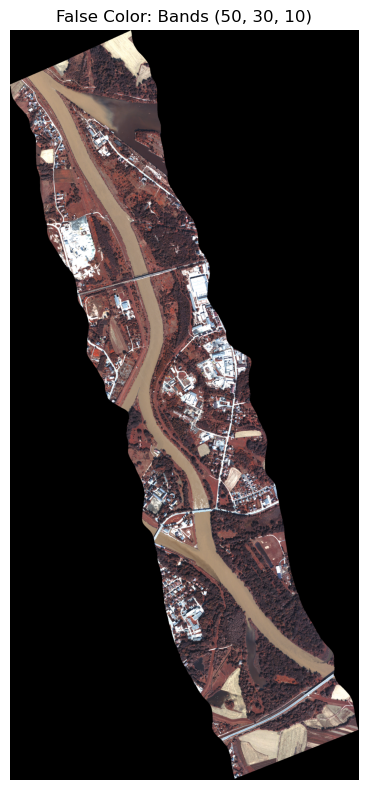

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def show_false_color(filepath, rgb_bands=(50, 30, 20)):
    """
    Wyświetla obraz BSQ w barwach fałszywych.
    rgb_bands: numery kanałów (uwaga: rasterio liczy od 1!)
    """
    with rasterio.open(filepath) as src:
        print(f"Wczytywanie kanałów: {rgb_bands}")
        print(f"Rozmiar: {src.width}x{src.height}, Liczba wszystkich pasm: {src.count}")
        
        r = src.read(rgb_bands[0])
        g = src.read(rgb_bands[1])
        b = src.read(rgb_bands[2])

        def normalize(band):

            band = band.astype(np.float32)
            p2, p98 = np.nanpercentile(band, (2, 98))
            if p98 == p2: return np.zeros_like(band)

            stretched = np.clip((band - p2) / (p98 - p2), 0, 1)
            return stretched

        rgb_img = np.dstack([normalize(r), normalize(g), normalize(b)])

        plt.figure(figsize=(10, 8))
        plt.imshow(rgb_img)
        plt.title(f"False Color: Bands {rgb_bands}")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

sciezka_do_pliku = "C:/Users\HP\Desktop\stuff\eolabs-main\lab_5\Obrazy_lotnicze/221000_Odra_HS_Blok_A_008_VS_join_atm.bsq" 

pasm_rgb = (50, 30, 10) 

show_false_color(sciezka_do_pliku, rgb_bands=pasm_rgb)

--- ANALIZA PLIKU ---
Plik: 221000_Odra_HS_Blok_A_008_VS_join_atm.bsq
Wymiary: 2001x4300 | Pasma: 456
Ostrzeżenie: Nie znaleziono metadanych. Używam 44 jako surowego indeksu.
Ostrzeżenie: Nie znaleziono metadanych. Używam 136 jako surowego indeksu.
Ostrzeżenie: Nie znaleziono metadanych. Używam 74 jako surowego indeksu.
Ostrzeżenie: Nie znaleziono metadanych. Używam 45 jako surowego indeksu.
Ostrzeżenie: Nie znaleziono metadanych. Używam 18 jako surowego indeksu.


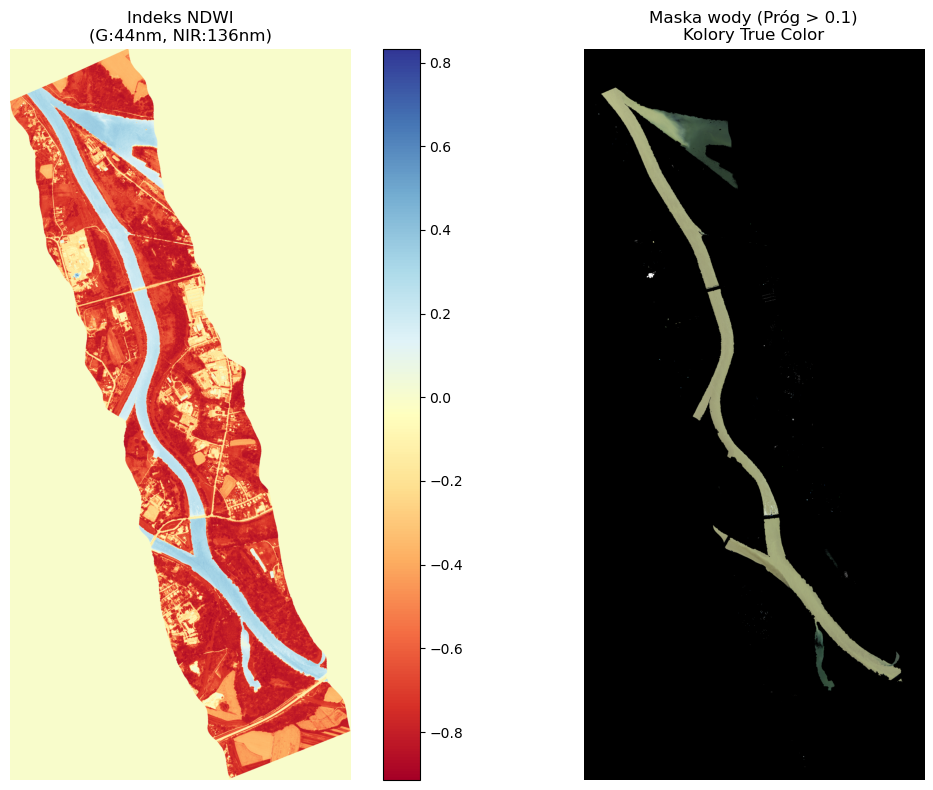

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

def get_band_index(src, wavelength_nm):
    """
    Znajduje indeks pasma najbliższy podanej długości fali (nm).
    Wykorzystuje tagi metadanych ENVI lub opisy pasm.
    """

    meta_wavelengths = src.tags().get('wavelength')
    
    if meta_wavelengths:
        try:
            wl_string = meta_wavelengths.replace('{', '').replace('}', '')
            wl_list = [float(x.strip()) for x in wl_string.split(',')]
            idx = np.argmin(np.abs(np.array(wl_list) - wavelength_nm)) + 1
            print(f"Dopasowano {wavelength_nm}nm -> Pasmo {idx} ({wl_list[idx-1]:.2f}nm)")
            return idx
        except (ValueError, AttributeError):
            pass
            
    if src.descriptions and src.descriptions[0] is not None:
        try:
            wl_list = [float(d.split()[0]) for d in src.descriptions]
            idx = np.argmin(np.abs(np.array(wl_list) - wavelength_nm)) + 1
            print(f"Dopasowano {wavelength_nm}nm z opisów -> Pasmo {idx}")
            return idx
        except (ValueError, IndexError):
            pass

    print(f"Ostrzeżenie: Nie znaleziono metadanych. Używam {wavelength_nm} jako surowego indeksu.")
    return int(wavelength_nm)

def show_water_mask_hdr(filepath, green_wl=560, nir_wl=842, rgb_wls=(650, 560, 480), threshold=0.1):
    target_path = filepath
    if filepath.lower().endswith('.hdr'):
        base_path = filepath.rsplit('.hdr', 1)[0]
        potential_exts = ['', '.bsq', '.dat', '.img', '.bil', '.bip']
        for ext in potential_exts:
            if os.path.exists(base_path + ext):
                target_path = base_path + ext
                break

    try:
        with rasterio.open(target_path) as src:
            print(f"--- ANALIZA PLIKU ---")
            print(f"Plik: {os.path.basename(target_path)}")
            print(f"Wymiary: {src.width}x{src.height} | Pasma: {src.count}")

            idx_green = get_band_index(src, green_wl)
            idx_nir = get_band_index(src, nir_wl)
            idx_rgb = [get_band_index(src, wl) for wl in rgb_wls]

            green = src.read(idx_green).astype(np.float32)
            nir = src.read(idx_nir).astype(np.float32)
            
            r = src.read(idx_rgb[0]).astype(np.float32)
            g = src.read(idx_rgb[1]).astype(np.float32)
            b = src.read(idx_rgb[2]).astype(np.float32)

            ndwi = (green - nir) / (green + nir + 1e-6)

            water_mask = ndwi > threshold

            def normalize(band):
                p2, p98 = np.nanpercentile(band, (2, 98))
                if p98 <= p2: return np.zeros_like(band)
                return np.clip((band - p2) / (p98 - p2), 0, 1)

            rgb_img = np.dstack([normalize(r), normalize(g), normalize(b)])

            water_only = np.zeros_like(rgb_img)
            water_only[water_mask] = rgb_img[water_mask]

            fig, ax = plt.subplots(1, 2, figsize=(16, 8))

            im1 = ax[0].imshow(ndwi, cmap='RdYlBu')
            ax[0].set_title(f"Indeks NDWI\n(G:{green_wl}nm, NIR:{nir_wl}nm)")
            fig.colorbar(im1, ax=ax[0], fraction=0.046, pad=0.04)
            
            ax[1].imshow(water_only)
            ax[1].set_title(f"Maska wody (Próg > {threshold})\nKolory True Color")
            
            for a in ax: a.axis('off')
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Błąd krytyczny: {e}")

sciezka_do_pliku = "C:/Users/HP/Desktop/stuff/eolabs-main/lab_5/Obrazy_lotnicze/221000_Odra_HS_Blok_A_008_VS_join_atm.hdr"

show_water_mask_hdr(
    sciezka_do_pliku,
    green_wl=44,     
    nir_wl=136,      
    rgb_wls=(74, 45, 18), 
    threshold=0.1   
)

--- ANALIZA: 221000_Odra_HS_Blok_A_008_VS_join_atm.bsq ---


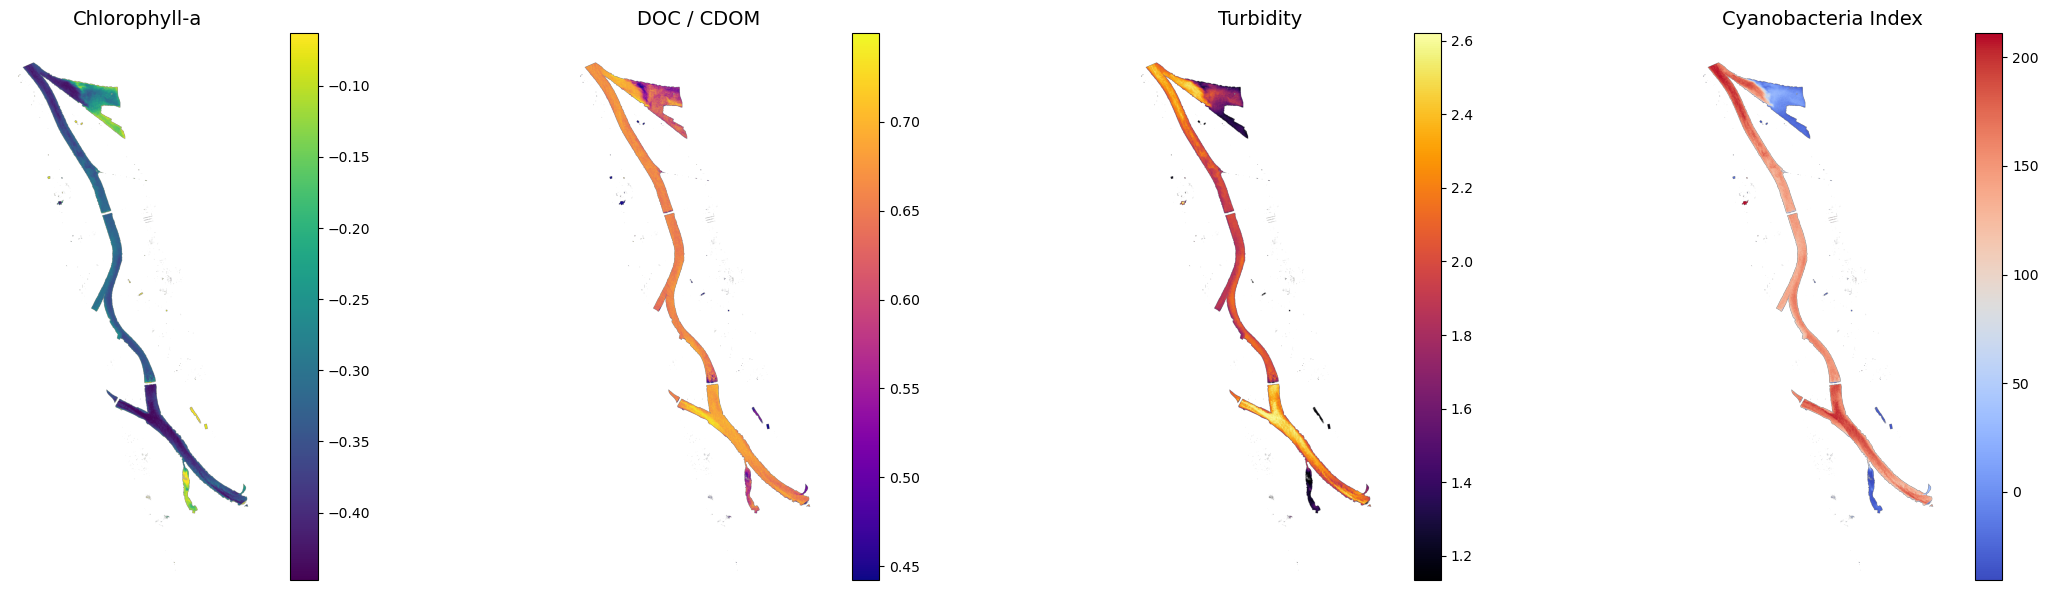

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

def get_band_index(src, wavelength_nm):
    meta_wavelengths = src.tags().get('wavelength')
    if meta_wavelengths:
        try:
            wl_string = meta_wavelengths.replace('{', '').replace('}', '')
            wl_list = [float(x.strip()) for x in wl_string.split(',')]
            idx = np.argmin(np.abs(np.array(wl_list) - wavelength_nm)) + 1
            return idx
        except (ValueError, AttributeError): pass
    if src.descriptions and src.descriptions[0] is not None:
        try:
            wl_list = [float(d.split()[0]) for d in src.descriptions]
            idx = np.argmin(np.abs(np.array(wl_list) - wavelength_nm)) + 1
            return idx
        except (ValueError, IndexError): pass
    return int(wavelength_nm)

def analyze_water_quality(filepath, blue_wl=480, green_wl=560, red_wl=650, 
                          red_edge_wl=705, nir_wl=840, threshold=0.1):
    target_path = filepath
    if filepath.lower().endswith('.hdr'):
        base_path = filepath.rsplit('.hdr', 1)[0]
        potential_exts = ['', '.bsq', '.dat', '.img', '.bil', '.bip']
        for ext in potential_exts:
            if os.path.exists(base_path + ext):
                target_path = base_path + ext
                break

    try:
        with rasterio.open(target_path) as src:
            print(f"--- ANALIZA: {os.path.basename(target_path)} ---")
            
            b = src.read(get_band_index(src, blue_wl)).astype(np.float32)
            g = src.read(get_band_index(src, green_wl)).astype(np.float32)
            r = src.read(get_band_index(src, red_wl)).astype(np.float32)
            re = src.read(get_band_index(src, red_edge_wl)).astype(np.float32)
            nir = src.read(get_band_index(src, nir_wl)).astype(np.float32)

            eps = 1e-6
            ndwi = (g - nir) / (g + nir + eps)
            water_mask = ndwi > threshold

            def apply_mask(data, mask):
                masked = data.copy()
                masked[~mask] = np.nan
                return masked

            chl = apply_mask((nir - r) / (nir + r + eps), water_mask)
            doc = apply_mask(np.log((g + eps) / (b + eps)), water_mask)
            turb = apply_mask(r / (nir + eps), water_mask)
            ci = apply_mask(re - (r + nir) / 2, water_mask)

            fig, axes = plt.subplots(1, 4, figsize=(24, 6))
            
            indices = [
                (chl, "Chlorophyll-a", "viridis"),
                (doc, "DOC / CDOM", "plasma"),
                (turb, "Turbidity", "inferno"),
                (ci, "Cyanobacteria Index", "coolwarm")
            ]

            for i, (data, title, cmap) in enumerate(indices):
                ax = axes[i]
                valid_data = data[~np.isnan(data)]
                
                if valid_data.size > 0:
                    vmin, vmax = np.percentile(valid_data, (2, 98))
                else:
                    vmin, vmax = 0, 1
                
                im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
                ax.set_title(title, fontsize=14)
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
                ax.axis('off')

            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Błąd: {e}")

sciezka = "C:/Users/HP/Desktop/stuff/eolabs-main/lab_5/Obrazy_lotnicze/221000_Odra_HS_Blok_A_008_VS_join_atm.hdr"

analyze_water_quality(
    sciezka,
    blue_wl=18, green_wl=45, red_wl=74, red_edge_wl=78, nir_wl=135,
    threshold=0.05
)

<>:89: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
<>:89: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_9032\1456538525.py:89: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
  sciezka_folder = "C:/Users\HP\Desktop\stuff\eolabs-main\lab_5\s2_tiff_bands"


--- ANALIZA FOLDERU: s2_tiff_bands ---


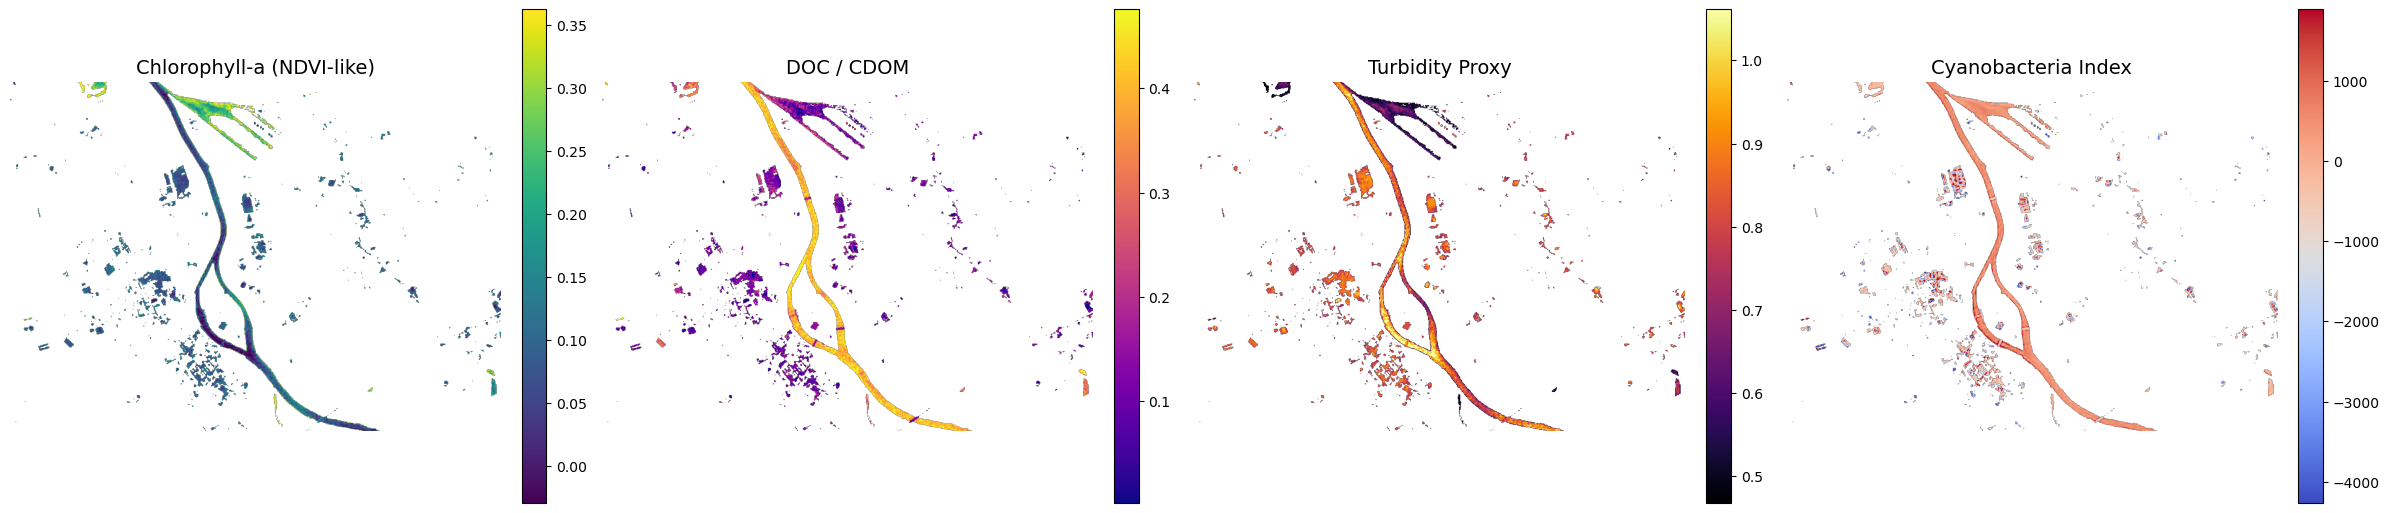

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

def load_sentinel_band(folder_path, band_suffix):
    pattern = os.path.join(folder_path, f"*{band_suffix}*")
    files = glob.glob(pattern)
    
    if not files:
        raise FileNotFoundError(f"Nie znaleziono pliku dla pasma: {band_suffix}")
    
    with rasterio.open(files[0]) as src:
        data = src.read(1).astype(np.float32)
        return data

def analyze_sentinel_water_quality(folder_path, threshold=0.0):
    print(f"--- ANALIZA FOLDERU: {os.path.basename(folder_path)} ---")
    
    try:
        b = load_sentinel_band(folder_path, "B02")
        g = load_sentinel_band(folder_path, "B03")
        r = load_sentinel_band(folder_path, "B04")
        re = load_sentinel_band(folder_path, "B05")
        nir = load_sentinel_band(folder_path, "B08")

        eps = 1e-6
        ndwi = (g - nir) / (g + nir + eps)
        water_mask = ndwi > threshold

        def apply_mask(data, mask):
            masked = np.copy(data)
            if masked.shape != mask.shape:
                masked = masked[:mask.shape[0], :mask.shape[1]]
            masked[~mask[:masked.shape[0], :masked.shape[1]]] = np.nan
            return masked

        chl = apply_mask((nir - r) / (nir + r + eps), water_mask)
        doc = apply_mask(np.log((g + eps) / (b + eps)), water_mask)
        turb = apply_mask(r / (nir + eps), water_mask)
        ci = apply_mask(re - (r + nir) / 2, water_mask)

        fig, axes = plt.subplots(1, 4, figsize=(24, 6))
        
        indices = [
            (chl, "Chlorophyll-a (NDVI-like)", "viridis"),
            (doc, "DOC / CDOM", "plasma"),
            (turb, "Turbidity Proxy", "inferno"),
            (ci, "Cyanobacteria Index", "coolwarm")
        ]

        for i, (data, title, cmap) in enumerate(indices):
            ax = axes[i]
            valid_data = data[~np.isnan(data)]
            
            if valid_data.size > 0:
                vmin, vmax = np.percentile(valid_data, (2, 98))
            else:
                vmin, vmax = 0, 1
            
            im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_title(title, fontsize=14)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Błąd podczas przetwarzania: {e}")

sciezka_folder = "C:/Users\HP\Desktop\stuff\eolabs-main\lab_5\s2_tiff_bands"

analyze_sentinel_water_quality(sciezka_folder, threshold=-0.2)

<>:14: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
<>:15: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
<>:16: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
<>:17: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
<>:14: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
<>:15: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
<>:16: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences wil

Wczytano 4 pasm.
Kształt macierzy widmowej: (448045, 4)


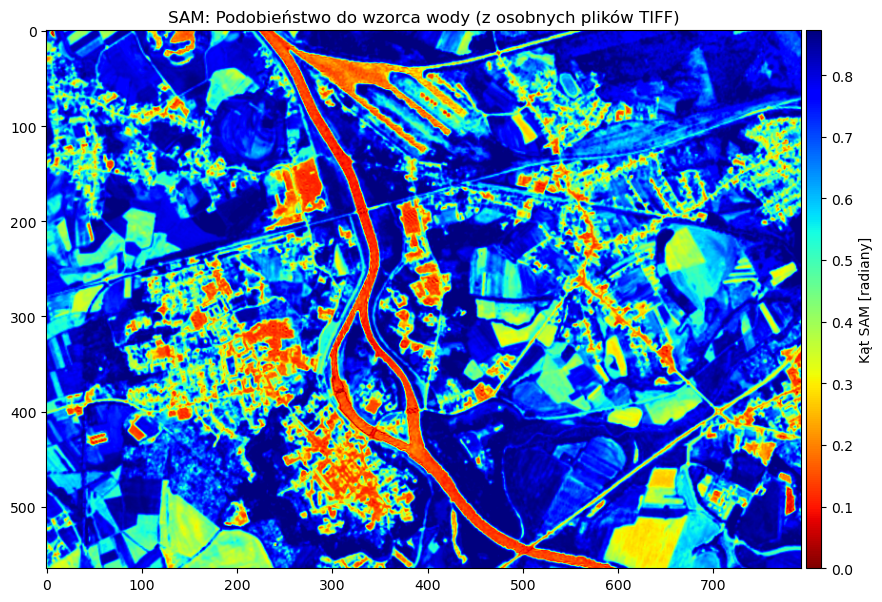

In [ ]:
import pandas as pd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import os
from mpl_toolkits.axes_grid1 import make_axes_locatable

folder_path = r'C:\Users\HP\Desktop\stuff\eolabs-main\lab_5\s2_tiff_bands'

band_files = {
    'B2': 'C:/Users\HP\Desktop\stuff\eolabs-main\lab_5\s2_tiff_bands/2025-06-15-00_00_2025-06-15-23_59_Sentinel-2_L2A_B02_(Raw).tiff',
    'B3': 'C:/Users\HP\Desktop\stuff\eolabs-main\lab_5\s2_tiff_bands/2025-06-15-00_00_2025-06-15-23_59_Sentinel-2_L2A_B03_(Raw).tiff',
    'B4': 'C:/Users\HP\Desktop\stuff\eolabs-main\lab_5\s2_tiff_bands/2025-06-15-00_00_2025-06-15-23_59_Sentinel-2_L2A_B04_(Raw).tiff',
    'B8': 'C:/Users\HP\Desktop\stuff\eolabs-main\lab_5\s2_tiff_bands/2025-06-15-00_00_2025-06-15-23_59_Sentinel-2_L2A_B08_(Raw).tiff'
}

bands_data = []
rows, cols = None, None

for band_name in ['B2', 'B3', 'B4', 'B8']:
    file_path = os.path.join(folder_path, band_files[band_name])
    
    with rasterio.open(file_path) as src:
        band_array = src.read(1).astype(np.float32)
        bands_data.append(band_array)
        
        if rows is None:
            rows, cols = band_array.shape

s2_data = np.array(bands_data)

if np.max(s2_data) > 10: 
    s2_data /= 10000.0

s2_spectra = s2_data.reshape((4, rows * cols)).T

def get_s2_from_csv(file_path):
    df = pd.read_csv(file_path)
    s2_wavelengths = [490, 560, 665, 842] 
    values = []
    for wl in s2_wavelengths:
        idx = (df.iloc[:, 0] - wl).abs().idxmin()
        values.append(df.iloc[idx, 1])
    val = np.array(values, dtype=np.float32)
    return val / 10000.0 if np.max(val) > 10 else val

ref_path = r"C:\Users\HP\Desktop\stuff\eolabs-main\lab_5\Water.csv"
ref_spectrum = get_s2_from_csv(ref_path)

print(f"Wczytano {len(bands_data)} pasm.")
print(f"Kształt macierzy widmowej: {s2_spectra.shape}")

dot_product = np.dot(s2_spectra, ref_spectrum)
norm_product = np.linalg.norm(s2_spectra, axis=1) * np.linalg.norm(ref_spectrum)

sam = np.arccos(np.clip(dot_product / (norm_product + 1e-9), -1, 1))
sam_map = sam.reshape((rows, cols))

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title('SAM: Podobieństwo do wzorca wody (z osobnych plików TIFF)')

map_plot = ax.imshow(sam_map, cmap='jet_r', vmin=0, vmax=np.nanpercentile(sam_map, 95))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.05)
plt.colorbar(map_plot, cax=cax, label='Kąt SAM [radiany]')
plt.show()